## 7a. Linear Regression Model Training and Testing

Code are following AAI 540 Lab 4

### Setup to Load Data from S3

In [8]:
# If you're using the default bucket, set DEFAULT_BUCKET = True; otherwise, if you're using a specific bucket, set it to False instead
DEFAULT_BUCKET = False

In [9]:
# Read from environment to use DEFAULT_BUCKET
# %store -r DEFAULT_BUCKET
# print(DEFAULT_BUCKET)

In [10]:
import boto3
import sagemaker
import pandas as pd
from pyathena import connect
import numpy as np
sess = sagemaker.Session()
DEFAULT_BUCKET=True
bucket = sess.default_bucket()
if DEFAULT_BUCKET is False:
    # Code to use a previously existing bucket
    pub_bucket = "usdmsaai540-spring2026-team1"
s3 = boto3.resource("s3")
role = sagemaker.get_execution_role()
region = boto3.Session().region_name

In [11]:

# Set S3 path to Parquet data
# if DEFAULT_BUCKET:
#     s3_path_parquet = f's3://{bucket}/CCPP/data/parquet/final_data_v2'
# else:
#     s3_path_parquet = f's3://{pub_bucket}/CCPP/data//parquet'

# Set Athena parameters
database_name = "ccpp_aws_fp"
table_name_csv = "final_data_csv"
table_name_parquet = "final_data_parquet_v4"

In [12]:
# Set S3 staging directory -- this is a temporary directory used for Athena queries
s3_staging_dir = "s3://{0}/athena/staging".format(bucket)
s3_staging_dir

's3://sagemaker-us-east-1-582544415612/athena/staging'

In [13]:
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)

In [14]:
from pyathena import connect

In [15]:

statement = """SELECT count(1) FROM {}.{}
    """.format(
    database_name, table_name_parquet
)

print(statement) 

SELECT count(1) FROM ccpp_aws_fp.final_data_parquet_v4
    


In [16]:

data_count= pd.read_sql(statement, conn)
total_records=data_count['_col0'].values[0]
total_records

/tmp/ipykernel_40214/3056553487.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_count= pd.read_sql(statement, conn)


14764

In [17]:
train_seq_id= int(total_records*0.4)
val_seq_id= train_seq_id+ int(total_records*0.4)


### Load Training Dataset (all year 2013 data)

In [18]:


statement = """SELECT * FROM {}.{}
    WHERE seq_id < {}
    ORDER BY seq_id""".format(
    database_name, table_name_parquet,train_seq_id
)

print(statement)

SELECT * FROM ccpp_aws_fp.final_data_parquet_v4
    WHERE seq_id < 5905
    ORDER BY seq_id


In [19]:
data_train = pd.read_sql(statement, conn)
data_train

/tmp/ipykernel_40214/3564220957.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_train = pd.read_sql(statement, conn)


,seq_id,ingestion_ts,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,1,2026-02-16 22:27:20.512,10.564,19.166,1043.6,2.3927,0.0,0.0,0.0,1020.1,90.0,1023.0,110.16
1,2,2026-02-16 22:27:20.512,10.572,19.119,1039.9,2.3732,0.0,0.0,0.0,1019.9,89.0,1023.0,109.23
2,3,2026-02-16 22:27:20.512,10.543,19.178,1041.0,2.3854,0.0,0.0,0.0,1019.8,91.2,1023.1,109.62
3,4,2026-02-16 22:27:20.512,10.458,19.180,1037.1,2.3825,0.0,0.0,0.0,1019.3,90.3,1022.3,108.88
4,5,2026-02-16 22:27:20.512,10.464,19.206,1043.5,2.4044,0.0,0.0,0.0,1019.1,90.3,1022.2,110.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5899,5900,2026-02-16 22:27:20.512,11.228,22.445,1066.7,3.9474,0.0,0.0,0.0,1016.2,32.3,1022.0,123.41
5900,5901,2026-02-16 22:27:20.512,11.227,22.547,1066.6,3.9705,0.0,0.0,0.0,1016.7,0.0,1021.9,122.89
5901,5902,2026-02-16 22:27:20.512,11.354,22.764,1067.4,4.0434,0.0,0.0,0.0,1017.2,29.3,1022.0,122.73
5902,5903,2026-02-16 22:27:20.512,11.398,22.773,1067.6,4.0607,0.0,0.0,0.0,1017.4,22.2,1021.9,122.31


### Load Validation Data 2014 January

In [20]:
statement = """SELECT * FROM {}.{}
    WHERE seq_id >= {} and seq_id < {}
    ORDER BY seq_id""".format(
    database_name, table_name_parquet,train_seq_id,val_seq_id
)

print(statement)

SELECT * FROM ccpp_aws_fp.final_data_parquet_v4
    WHERE seq_id >= 5905 and seq_id < 11810
    ORDER BY seq_id


In [21]:
data_val = pd.read_sql(statement, conn)
data_val

/tmp/ipykernel_40214/3443150230.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_val = pd.read_sql(statement, conn)


,seq_id,ingestion_ts,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,5905,2026-02-16 22:27:20.512,11.408,22.939,1067.9,4.1203,0.1,0.0,0.0,1017.3,28.1,1022.0,121.71
1,5906,2026-02-16 22:27:20.512,11.333,22.956,1067.9,4.1384,54.7,0.2,1.0,1017.0,50.0,1022.1,121.45
2,5907,2026-02-16 22:27:20.512,11.331,22.849,1068.2,4.2258,202.3,0.7,2.0,1016.6,11.9,1022.9,121.53
3,5908,2026-02-16 22:27:20.512,11.266,22.845,1068.2,4.2074,387.6,1.4,4.0,1016.2,24.7,1022.9,121.32
4,5909,2026-02-16 22:27:20.512,11.436,22.987,1068.9,4.2299,527.9,1.9,5.0,1015.8,44.0,1022.9,121.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5900,11805,2026-02-16 22:27:20.512,13.258,30.137,1099.9,4.3847,0.0,0.0,0.0,1009.9,3.6,1011.9,148.37
5901,11806,2026-02-16 22:27:20.512,13.260,30.036,1100.0,4.3804,0.0,0.0,0.0,1009.8,0.0,1011.9,148.40
5902,11807,2026-02-16 22:27:20.512,13.239,30.033,1100.0,4.3641,0.0,0.0,0.0,1009.9,3.2,1011.9,148.65
5903,11808,2026-02-16 22:27:20.512,13.104,29.681,1100.1,4.3198,0.0,0.0,0.0,1009.8,2.6,1012.0,147.88


### Load Test Data 2014 February

In [22]:
statement = """SELECT * FROM {}.{}
    WHERE seq_id >= {} 
    ORDER BY seq_id""".format(
    database_name, table_name_parquet,val_seq_id
)

print(statement)

SELECT * FROM ccpp_aws_fp.final_data_parquet_v4
    WHERE seq_id >= 11810 
    ORDER BY seq_id


In [23]:
data_test = pd.read_sql(statement, conn)
data_test

/tmp/ipykernel_40214/2304454054.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_test = pd.read_sql(statement, conn)


,seq_id,ingestion_ts,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,11810,2026-02-16 22:27:20.512,13.118,29.805,1099.9,4.3594,0.0,0.0,0.0,1010.2,0.0,1011.9,147.21
1,11811,2026-02-16 22:27:20.512,13.160,30.018,1099.9,4.4136,0.0,0.0,0.0,1010.3,1.0,1011.9,147.14
2,11812,2026-02-16 22:27:20.512,13.204,30.199,1099.9,4.4296,0.0,0.0,0.0,1010.3,0.0,1012.0,147.66
3,11813,2026-02-16 22:27:20.512,13.121,29.979,1099.9,4.3978,19.9,0.1,0.0,1010.2,0.0,1012.0,147.14
4,11814,2026-02-16 22:27:20.512,13.094,29.712,1100.0,4.3754,144.2,0.5,1.0,1009.8,0.0,1010.5,146.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2950,14760,2026-02-16 22:27:20.512,10.411,19.087,1037.0,3.1661,0.0,0.0,0.0,1028.5,78.2,1029.6,109.08
2951,14761,2026-02-16 22:27:20.512,10.344,19.016,1037.6,3.1923,0.0,0.0,0.0,1028.6,78.2,1028.8,108.79
2952,14762,2026-02-16 22:27:20.512,10.462,18.857,1038.0,3.3128,0.0,0.0,0.0,1028.5,46.0,1028.7,107.81
2953,14763,2026-02-16 22:27:20.512,11.771,23.563,1076.9,3.9831,0.0,0.0,0.0,1028.7,46.0,1028.7,131.41


### Prepare the dataset

In [24]:
data_train = data_train.drop(['seq_id', 'ingestion_ts'], axis=1)
data_train

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,10.564,19.166,1043.6,2.3927,0.0,0.0,0.0,1020.1,90.0,1023.0,110.16
1,10.572,19.119,1039.9,2.3732,0.0,0.0,0.0,1019.9,89.0,1023.0,109.23
2,10.543,19.178,1041.0,2.3854,0.0,0.0,0.0,1019.8,91.2,1023.1,109.62
3,10.458,19.180,1037.1,2.3825,0.0,0.0,0.0,1019.3,90.3,1022.3,108.88
4,10.464,19.206,1043.5,2.4044,0.0,0.0,0.0,1019.1,90.3,1022.2,110.09
...,...,...,...,...,...,...,...,...,...,...,...
5899,11.228,22.445,1066.7,3.9474,0.0,0.0,0.0,1016.2,32.3,1022.0,123.41
5900,11.227,22.547,1066.6,3.9705,0.0,0.0,0.0,1016.7,0.0,1021.9,122.89
5901,11.354,22.764,1067.4,4.0434,0.0,0.0,0.0,1017.2,29.3,1022.0,122.73
5902,11.398,22.773,1067.6,4.0607,0.0,0.0,0.0,1017.4,22.2,1021.9,122.31


In [25]:
data_val = data_val.drop(['seq_id', 'ingestion_ts'], axis=1)
data_val

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,11.408,22.939,1067.9,4.1203,0.1,0.0,0.0,1017.3,28.1,1022.0,121.71
1,11.333,22.956,1067.9,4.1384,54.7,0.2,1.0,1017.0,50.0,1022.1,121.45
2,11.331,22.849,1068.2,4.2258,202.3,0.7,2.0,1016.6,11.9,1022.9,121.53
3,11.266,22.845,1068.2,4.2074,387.6,1.4,4.0,1016.2,24.7,1022.9,121.32
4,11.436,22.987,1068.9,4.2299,527.9,1.9,5.0,1015.8,44.0,1022.9,121.70
...,...,...,...,...,...,...,...,...,...,...,...
5900,13.258,30.137,1099.9,4.3847,0.0,0.0,0.0,1009.9,3.6,1011.9,148.37
5901,13.260,30.036,1100.0,4.3804,0.0,0.0,0.0,1009.8,0.0,1011.9,148.40
5902,13.239,30.033,1100.0,4.3641,0.0,0.0,0.0,1009.9,3.2,1011.9,148.65
5903,13.104,29.681,1100.1,4.3198,0.0,0.0,0.0,1009.8,2.6,1012.0,147.88


In [26]:
data_test = data_test.drop(['seq_id', 'ingestion_ts'], axis=1)
data_test

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,13.118,29.805,1099.9,4.3594,0.0,0.0,0.0,1010.2,0.0,1011.9,147.21
1,13.160,30.018,1099.9,4.4136,0.0,0.0,0.0,1010.3,1.0,1011.9,147.14
2,13.204,30.199,1099.9,4.4296,0.0,0.0,0.0,1010.3,0.0,1012.0,147.66
3,13.121,29.979,1099.9,4.3978,19.9,0.1,0.0,1010.2,0.0,1012.0,147.14
4,13.094,29.712,1100.0,4.3754,144.2,0.5,1.0,1009.8,0.0,1010.5,146.55
...,...,...,...,...,...,...,...,...,...,...,...
2950,10.411,19.087,1037.0,3.1661,0.0,0.0,0.0,1028.5,78.2,1029.6,109.08
2951,10.344,19.016,1037.6,3.1923,0.0,0.0,0.0,1028.6,78.2,1028.8,108.79
2952,10.462,18.857,1038.0,3.3128,0.0,0.0,0.0,1028.5,46.0,1028.7,107.81
2953,11.771,23.563,1076.9,3.9831,0.0,0.0,0.0,1028.7,46.0,1028.7,131.41


In [27]:
data_batch = data_test.drop(['gt_energy_yield'], axis=1)
data_batch

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure
0,13.118,29.805,1099.9,4.3594,0.0,0.0,0.0,1010.2,0.0,1011.9
1,13.160,30.018,1099.9,4.4136,0.0,0.0,0.0,1010.3,1.0,1011.9
2,13.204,30.199,1099.9,4.4296,0.0,0.0,0.0,1010.3,0.0,1012.0
3,13.121,29.979,1099.9,4.3978,19.9,0.1,0.0,1010.2,0.0,1012.0
4,13.094,29.712,1100.0,4.3754,144.2,0.5,1.0,1009.8,0.0,1010.5
...,...,...,...,...,...,...,...,...,...,...
2950,10.411,19.087,1037.0,3.1661,0.0,0.0,0.0,1028.5,78.2,1029.6
2951,10.344,19.016,1037.6,3.1923,0.0,0.0,0.0,1028.6,78.2,1028.8
2952,10.462,18.857,1038.0,3.3128,0.0,0.0,0.0,1028.5,46.0,1028.7
2953,11.771,23.563,1076.9,3.9831,0.0,0.0,0.0,1028.7,46.0,1028.7


In [28]:
prefix = "CCPP-enery-prediction-linear-regression"

In [29]:
s3 = boto3.client("s3")

train_file = "train_data.csv"
df = data_train.copy()
cols = df.columns.tolist()
df = df[[cols[-1]] + cols[:-1]]
df.to_csv(train_file, index=False, header=False)
s3.upload_file(train_file, bucket, "{}/train/{}".format(prefix, train_file))


validation_file = "validation_data.csv"
df = data_val.copy()
cols = df.columns.tolist()
df = df[[cols[-1]] + cols[:-1]]
df.to_csv(train_file, index=False, header=False)
s3.upload_file(train_file, bucket, "{}/validation/{}".format(prefix, validation_file))

test_file = "test_data.csv"
df = data_test.copy()
cols = df.columns.tolist()
df = df[[cols[-1]] + cols[:-1]]
df.to_csv(train_file, index=False, header=False)
s3.upload_file(train_file, bucket, "{}/testing/{}".format(prefix, test_file))

batch_file = "batch_data.csv"
df = data_batch.copy()
df.to_csv(train_file, index=False, header=False)
s3.upload_file(train_file, bucket, "{}/batch/{}".format(prefix, batch_file))


In [30]:
data_train

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,10.564,19.166,1043.6,2.3927,0.0,0.0,0.0,1020.1,90.0,1023.0,110.16
1,10.572,19.119,1039.9,2.3732,0.0,0.0,0.0,1019.9,89.0,1023.0,109.23
2,10.543,19.178,1041.0,2.3854,0.0,0.0,0.0,1019.8,91.2,1023.1,109.62
3,10.458,19.180,1037.1,2.3825,0.0,0.0,0.0,1019.3,90.3,1022.3,108.88
4,10.464,19.206,1043.5,2.4044,0.0,0.0,0.0,1019.1,90.3,1022.2,110.09
...,...,...,...,...,...,...,...,...,...,...,...
5899,11.228,22.445,1066.7,3.9474,0.0,0.0,0.0,1016.2,32.3,1022.0,123.41
5900,11.227,22.547,1066.6,3.9705,0.0,0.0,0.0,1016.7,0.0,1021.9,122.89
5901,11.354,22.764,1067.4,4.0434,0.0,0.0,0.0,1017.2,29.3,1022.0,122.73
5902,11.398,22.773,1067.6,4.0607,0.0,0.0,0.0,1017.4,22.2,1021.9,122.31


### Model Training Setup and Training

In [31]:
%%time
from time import gmtime, strftime

job_name = "lr-" + strftime("%Y-%m-%d-%H-%M-%S", gmtime())
output_location = "s3://{}/{}/output/{}".format(bucket, prefix, job_name)
image = sagemaker.image_uris.retrieve(
    framework="linear-learner",   # built-in algorithm for regression/classification
    region=boto3.Session().region_name,
    version="latest"               # always safe to use "latest"
)

linear_estimator = sagemaker.estimator.Estimator(
    image,
    role,
    instance_count=1,
    instance_type="ml.m5.large",
    volume_size=50,
    input_mode="File",
    output_path=output_location,
    sagemaker_session=sess,
)
linear_estimator.set_hyperparameters(
    predictor_type="regressor",   # must set this for regression
    mini_batch_size=100,          # batch size for training
    epochs=15,                    # number of passes over the dataset
    learning_rate=0.1,           # similar to eta
    optimizer="sgd"              # can also be 'sgd', 'ftrl'
)
train_data = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/train".format(bucket, prefix),
    distribution="FullyReplicated",
    content_type="text/csv",
    s3_data_type="S3Prefix",
)
validation_data = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/validation".format(bucket, prefix),
    distribution="FullyReplicated",
    content_type="text/csv",
    s3_data_type="S3Prefix",
)
data_channels = {"train": train_data, "validation": validation_data}

# Start training by calling the fit method in the estimator
linear_estimator.fit(inputs=data_channels, job_name=job_name, logs=True)


INFO:sagemaker:Creating training-job with name: lr-2026-02-18-06-51-59


2026-02-18 06:52:03 Starting - Starting the training job...
2026-02-18 06:52:17 Starting - Preparing the instances for training...
2026-02-18 06:52:41 Downloading - Downloading input data...
2026-02-18 06:53:26 Downloading - Downloading the training image........Docker entrypoint called with argument(s): train
Running default environment configuration script
[02/18/2026 06:54:39 INFO 140400034662208] Reading default configuration from /opt/amazon/lib/python3.8/site-packages/algorithm/resources/default-input.json: {'mini_batch_size': '1000', 'epochs': '15', 'feature_dim': 'auto', 'use_bias': 'true', 'binary_classifier_model_selection_criteria': 'accuracy', 'f_beta': '1.0', 'target_recall': '0.8', 'target_precision': '0.8', 'num_models': 'auto', 'num_calibration_samples': '10000000', 'init_method': 'uniform', 'init_scale': '0.07', 'init_sigma': '0.01', 'init_bias': '0.0', 'optimizer': 'auto', 'loss': 'auto', 'margin': '1.0', 'quantile': '0.5', 'loss_insensitivity': '0.01', 'huber_delta':

### Setup Batch Transfomer Estimator

In [33]:
%%time

linear_transformer = linear_estimator.transformer(1, "ml.m5.xlarge")

# start a transform job
input_location = "s3://{}/{}/batch".format(
    bucket, prefix
)  
linear_transformer.transform(input_location, content_type="text/csv", split_type="Line")
linear_transformer.wait()

INFO:sagemaker:Creating model with name: linear-learner-2026-02-18-06-55-47-292
INFO:sagemaker:Creating transform job with name: linear-learner-2026-02-18-06-55-47-983


...................................Docker entrypoint called with argument(s): serve
Docker entrypoint called with argument(s): serve
Running default environment configuration script
[02/18/2026 07:01:34 INFO 140298634778432] Memory profiler is not enabled by the environment variable ENABLE_PROFILER.
/opt/amazon/lib/python3.8/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:495: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if cons['type'] is 'ineq':
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:743: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if len(self.X_min) is not 0:
Running default environment configuration script
[02/18/2026 07:01:34 INFO 140298634778432] Memory profiler is not enabled by the environment variable ENABLE_PROFILER.
/opt/amazon/lib/python3.8/site-packages/mxnet/model.py:97

### Plot the Batch Transform Result Compare to Ground Truth

In [34]:
import re


def get_csv_output_from_s3(s3uri, batch_file):
    file_name = "{}.out".format(batch_file)
    match = re.match("s3://([^/]+)/(.*)", "{}/{}".format(s3uri, file_name))
    output_bucket, output_prefix = match.group(1), match.group(2)
    s3.download_file(output_bucket, output_prefix, file_name)
    return pd.read_csv(file_name, sep=",", header=None)

In [35]:
s3 = boto3.client("s3")

In [36]:
output_df = get_csv_output_from_s3(linear_transformer.output_path, batch_file)
output_df.head(8)

,0
0,"{""score"":149.128402709960938}"
1,"{""score"":149.594345092773438}"
2,"{""score"":150.123092651367188}"
3,"{""score"":149.252182006835938}"
4,"{""score"":148.629623413085938}"
5,"{""score"":148.108810424804688}"
6,"{""score"":149.091018676757812}"
7,"{""score"":150.281570434570312}"


In [37]:
import json
output_df[0].apply(lambda x : json.loads(x)["score"])

0       149.128403
1       149.594345
2       150.123093
3       149.252182
4       148.629623
           ...    
2950    105.837845
2951    105.273300
2952    105.872971
2953    127.859573
2954    122.679276
Name: 0, Length: 2955, dtype: float64

In [38]:
compare_df = data_test[['gt_energy_yield']]

In [39]:
combined_df = pd.concat([compare_df, output_df[0].apply(lambda x : json.loads(x)["score"])], axis=1)

In [40]:
combined_df.rename(columns={0: 'Predited Energy'}, inplace=True)

In [41]:
combined_df

,gt_energy_yield,Predited Energy
0,147.21,149.128403
1,147.14,149.594345
2,147.66,150.123093
3,147.14,149.252182
4,146.55,148.629623
...,...,...
2950,109.08,105.837845
2951,108.79,105.273300
2952,107.81,105.872971
2953,131.41,127.859573


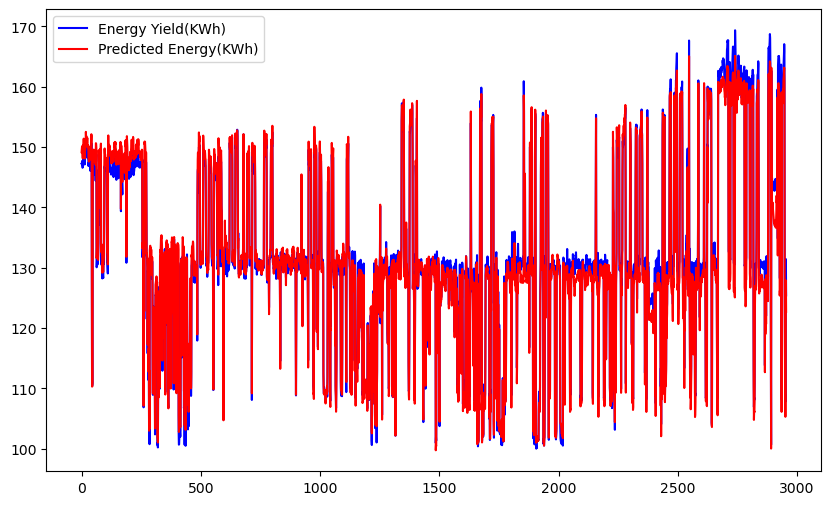

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Plotting the first column with a solid line
plt.plot(combined_df.index, combined_df['gt_energy_yield'], color='blue', label='Energy Yield(KWh)')

# Plotting the second column with a dotted line
plt.plot(combined_df.index, combined_df['Predited Energy'], color='red', label='Predicted Energy(KWh)')
plt.legend()
# Show plot
plt.show()

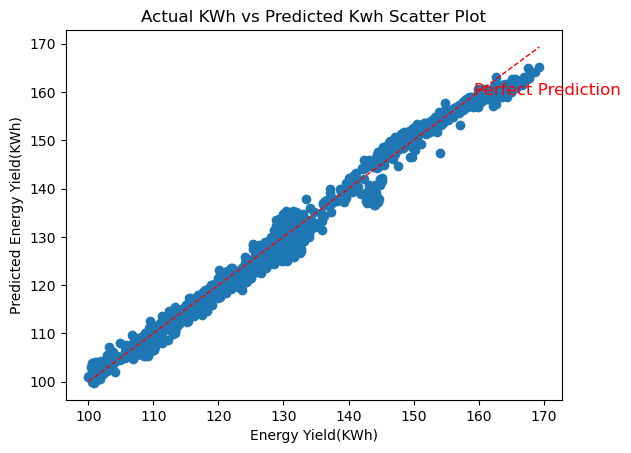

In [43]:
plt.figure()
plt.scatter(combined_df['gt_energy_yield'], combined_df['Predited Energy'])
y_test = combined_df['gt_energy_yield']
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
plt.text(y_test.max()-10, y_test.max()-10, 'Perfect Prediction', color='red', fontsize=12)    
plt.xlabel("Energy Yield(KWh)")
plt.ylabel("Predicted Energy Yield(KWh)")
plt.title("Actual KWh vs Predicted Kwh Scatter Plot")


plt.show()

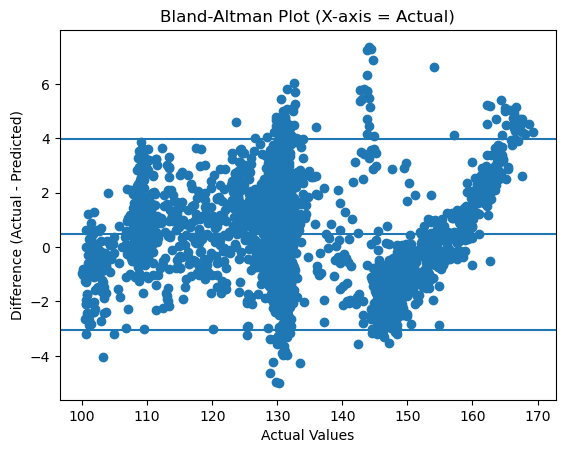

In [44]:
differences = combined_df['gt_energy_yield']-combined_df['Predited Energy']

mean_diff = np.mean(differences)
std_diff = np.std(differences)

upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

# Plot
plt.figure()
plt.scatter(combined_df['gt_energy_yield'], differences)

plt.axhline(mean_diff)
plt.axhline(upper_limit)
plt.axhline(lower_limit)

plt.xlabel("Actual Values")
plt.ylabel("Difference (Actual - Predicted)")
plt.title("Bland-Altman Plot (X-axis = Actual)")

plt.show()

In [45]:
linear_estimator.model_data

's3://sagemaker-us-east-1-582544415612/CCPP-enery-prediction-linear-regression/output/lr-2026-02-18-06-51-59/lr-2026-02-18-06-51-59/output/model.tar.gz'

In [28]:
%%html

<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>